Initially, a representative selection of thermal images was annotated by three members of the team. The goal is to obtain high-quality reference data to enable a meaningful comparison with the model’s outputs.
After completing the annotation process, the results from the different annotators are going to be compared to assess potential human error.


# **COMPARISON WITH THERMAL ANOTATED IMAGES**

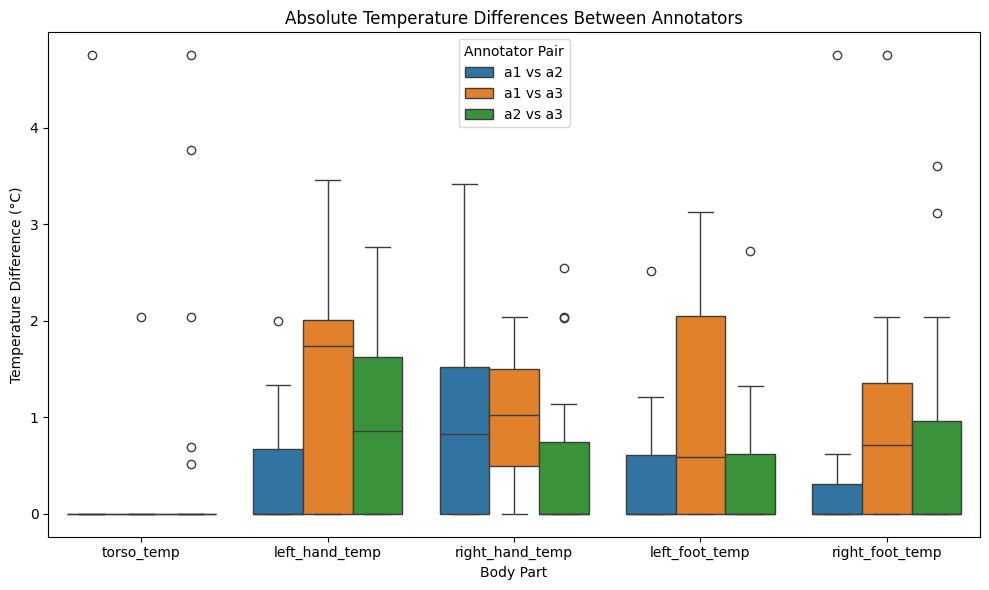

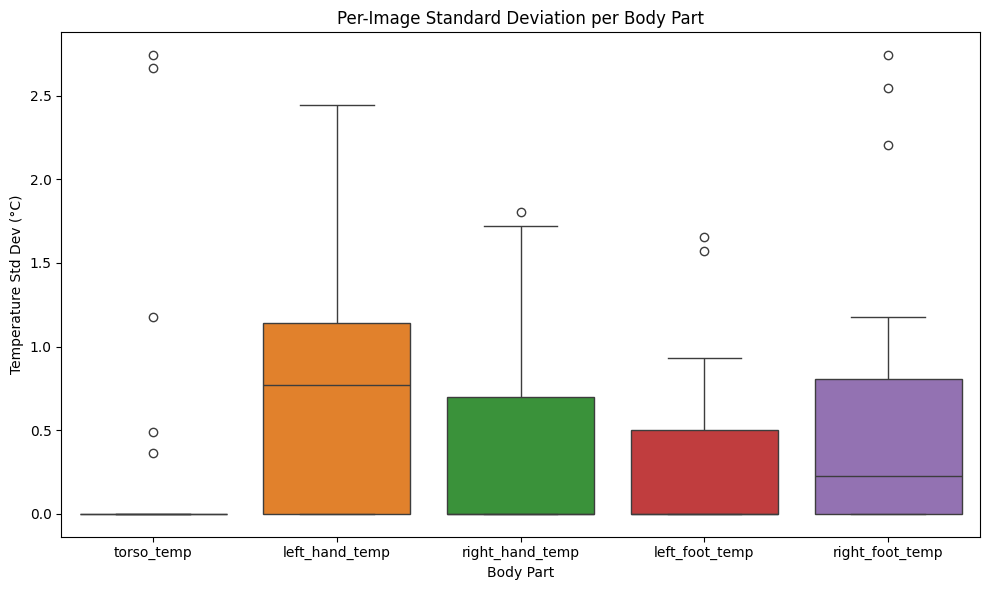

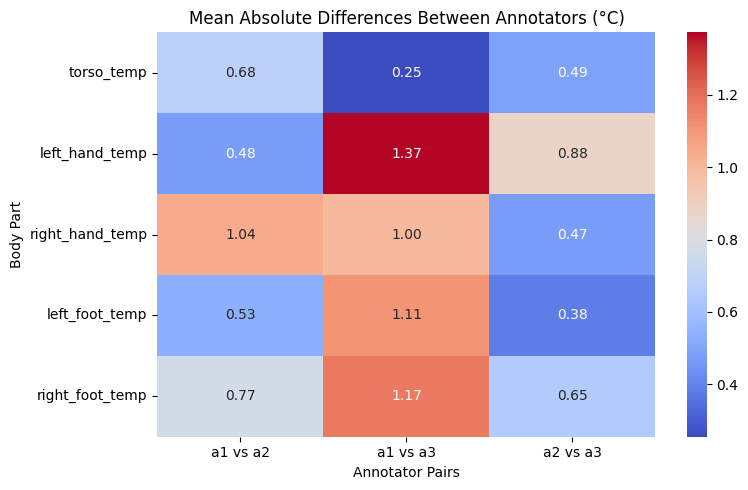

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# 1: we load the 3 CSVs from the annotators
# -----------------------------
annotator1 = pd.read_csv("/content/validation_ares_with_temps.csv")
annotator2 = pd.read_csv("/content/validation_jana_with_temps.csv")
annotator3 = pd.read_csv("/content/validation_meri_with_temps.csv")

# -----------------------------
# 2: we extract relevant columns and rename
# -----------------------------
temp_cols = ['Image Name', 'torso_temp', 'left_hand_temp', 'right_hand_temp', 'left_foot_temp', 'right_foot_temp']

a1 = annotator1[temp_cols].add_suffix('_a1')
a2 = annotator2[temp_cols].add_suffix('_a2')
a3 = annotator3[temp_cols].add_suffix('_a3')

# -----------------------------
# 3: we merge all three by image name
# -----------------------------
merged = a1.merge(a2, left_on='Image Name_a1', right_on='Image Name_a2')
merged = merged.merge(a3, left_on='Image Name_a1', right_on='Image Name_a3')
merged = merged.rename(columns={'Image Name_a1': 'Image Name'})
merged = merged.drop(columns=['Image Name_a2', 'Image Name_a3'])

# -----------------------------
# 4: calculation of the std and range per body part
# -----------------------------
temp_parts = ['torso_temp', 'left_hand_temp', 'right_hand_temp', 'left_foot_temp', 'right_foot_temp']

for part in temp_parts:
    merged[f'{part}_std'] = merged[[f'{part}_a1', f'{part}_a2', f'{part}_a3']].std(axis=1)
    merged[f'{part}_range'] = merged[[f'{part}_a1', f'{part}_a2', f'{part}_a3']].max(axis=1) - \
                              merged[[f'{part}_a1', f'{part}_a2', f'{part}_a3']].min(axis=1)

# -----------------------------
# 5: boxplot of pairwise differences
# -----------------------------
diffs = []

for part in temp_parts:
    for i, j in [('a1', 'a2'), ('a1', 'a3'), ('a2', 'a3')]:
        col1 = f'{part}_{i}'
        col2 = f'{part}_{j}'
        diff = merged[col1] - merged[col2]
        diffs.append(pd.DataFrame({
            'Part': part,
            'Difference': diff.abs(),
            'Pair': f'{i} vs {j}'
        }))

diff_df = pd.concat(diffs, ignore_index=True)

plt.figure(figsize=(10, 6))
sns.boxplot(data=diff_df, x='Part', y='Difference', hue='Pair')
plt.title("Absolute Temperature Differences Between Annotators")
plt.ylabel("Temperature Difference (°C)")
plt.xlabel("Body Part")
plt.legend(title='Annotator Pair')
plt.tight_layout()
plt.show()

# -----------------------------
# 6: standard deviation boxplot per part
# -----------------------------
std_df = merged[[f'{part}_std' for part in temp_parts]]
std_df.columns = temp_parts

plt.figure(figsize=(10, 6))
sns.boxplot(data=std_df)
plt.title("Per-Image Standard Deviation per Body Part")
plt.ylabel("Temperature Std Dev (°C)")
plt.xlabel("Body Part")
plt.tight_layout()
plt.show()

# -----------------------------
# 7: heatmap of mean absolute differences
# -----------------------------
heat_data = []

for part in temp_parts:
    row = []
    for i, j in [('a1', 'a2'), ('a1', 'a3'), ('a2', 'a3')]:
        col1 = f'{part}_{i}'
        col2 = f'{part}_{j}'
        diff = (merged[col1] - merged[col2]).abs().mean()
        row.append(diff)
    heat_data.append(row)

heat_matrix = np.array(heat_data)
plt.figure(figsize=(8, 5))
sns.heatmap(heat_matrix, annot=True, fmt=".2f", cmap='coolwarm',
            xticklabels=['a1 vs a2', 'a1 vs a3', 'a2 vs a3'],
            yticklabels=temp_parts)
plt.title("Mean Absolute Differences Between Annotators (°C)")
plt.xlabel("Annotator Pairs")
plt.ylabel("Body Part")
plt.tight_layout()
plt.show()


CONCLUSIONS:
- **Absolute Temperature Differences from Annotators**: There is high consistency in torso temperature annotations, with all annotator pairs showing zero difference. In contrast, the extremities—particularly the left hand and left foot— have more variability.
  - Among the annotator pairs, a1 and a3 have the largest differences across most body parts.

- **Per-Image Standard Deviation Per-Body Part**: The per-image standard deviation plot shows very good consistency in torso temperature annotations. In contrast, the left hand exhibits the highest variability, followed by the right hand, right foot, and left foot.

- **Mean Absolute Differences Between Annotators:** The heatmap highlights the average temperature differences between annotators across body parts. The largest discrepancies appear in the left hand (up to 1.37°C for a1 vs. a3) and feet (up to 1.17°C), while the torso shows minimal deviation (as low as 0.25°C).


With this irregular and overall not consistent results, the process needs to be repeated.


# **COMPARISON WITH RGB IMAGES (VISUAL IMAGES)**

As the previous results were not satisfactory, the annotation process was repeated, this time using visual images where the babies’ body parts were much easier to identify, making the process more manageable and less prone to error.

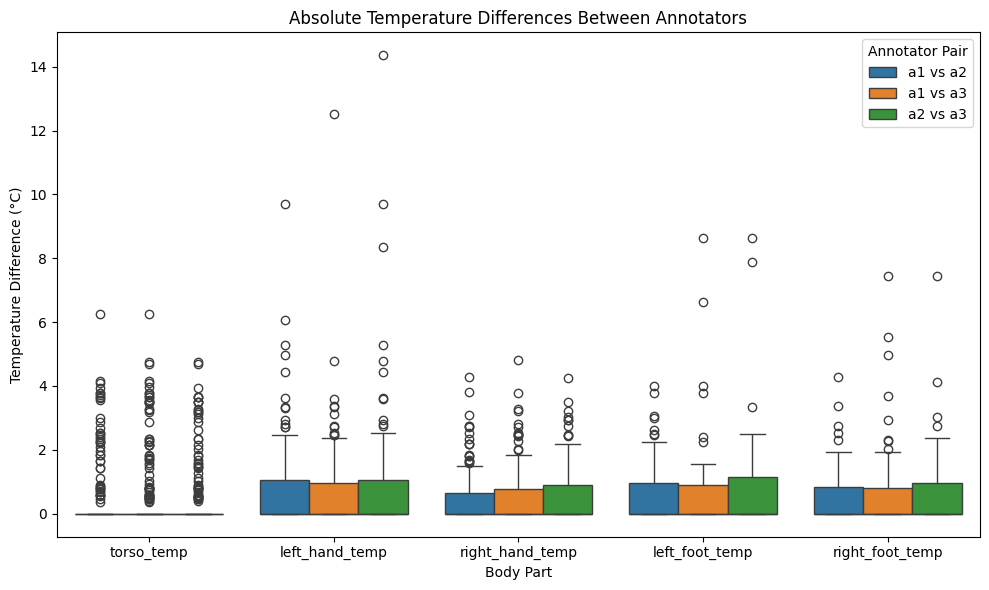

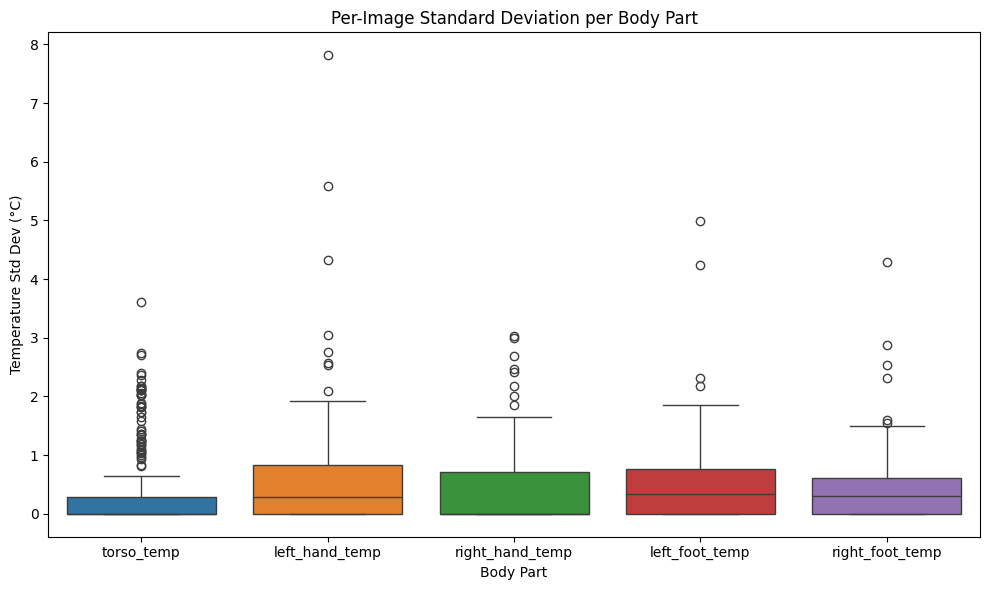

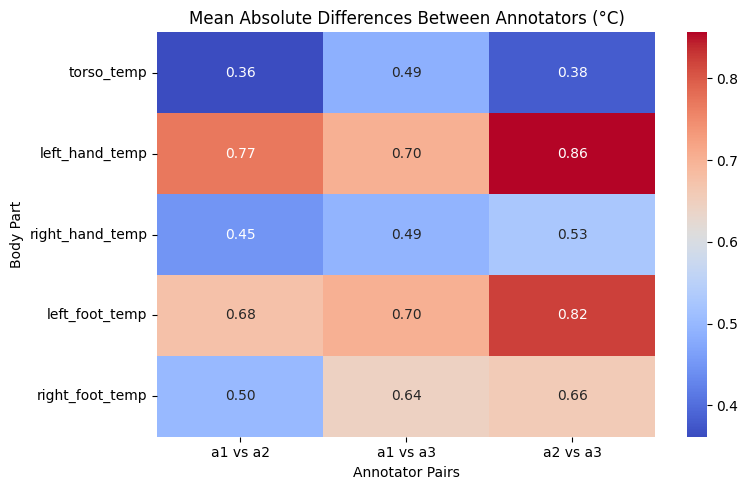

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# 1: we load the 3 CSVs from the annotators
# -----------------------------
annotator1 = pd.read_csv("/content/output_img_vis_ARES_with_temps.csv")
annotator2 = pd.read_csv("/content/output_img_vis_jana_with_temps.csv")
annotator3 = pd.read_csv("/content/output_img1_vis_meri_with_temps.csv")

# -----------------------------
# 2: we then extract relevant columns and rename
# -----------------------------
temp_cols = ['Image Path', 'torso_temp', 'left_hand_temp', 'right_hand_temp', 'left_foot_temp', 'right_foot_temp']

a1 = annotator1[temp_cols].add_suffix('_a1')
a2 = annotator2[temp_cols].add_suffix('_a2')
a3 = annotator3[temp_cols].add_suffix('_a3')

# -----------------------------
# 3: we merge all three by image name
# -----------------------------
merged = a1.merge(a2, left_on='Image Path_a1', right_on='Image Path_a2')
merged = merged.merge(a3, left_on='Image Path_a1', right_on='Image Path_a3')
merged = merged.rename(columns={'Image Path_a1': 'Image Path'})
merged = merged.drop(columns=['Image Path_a2', 'Image Path_a3'])

# -----------------------------
# 4: we calculate std and range per body part
# -----------------------------
temp_parts = ['torso_temp', 'left_hand_temp', 'right_hand_temp', 'left_foot_temp', 'right_foot_temp']

for part in temp_parts:
    merged[f'{part}_std'] = merged[[f'{part}_a1', f'{part}_a2', f'{part}_a3']].std(axis=1)
    merged[f'{part}_range'] = merged[[f'{part}_a1', f'{part}_a2', f'{part}_a3']].max(axis=1) - \
                              merged[[f'{part}_a1', f'{part}_a2', f'{part}_a3']].min(axis=1)

# -----------------------------
# 5: boxplot of pairwise differences
# -----------------------------
diffs = []

for part in temp_parts:
    for i, j in [('a1', 'a2'), ('a1', 'a3'), ('a2', 'a3')]:
        col1 = f'{part}_{i}'
        col2 = f'{part}_{j}'
        diff = merged[col1] - merged[col2]
        diffs.append(pd.DataFrame({
            'Part': part,
            'Difference': diff.abs(),
            'Pair': f'{i} vs {j}'
        }))

diff_df = pd.concat(diffs, ignore_index=True)

plt.figure(figsize=(10, 6))
sns.boxplot(data=diff_df, x='Part', y='Difference', hue='Pair')
plt.title("Absolute Temperature Differences Between Annotators")
plt.ylabel("Temperature Difference (°C)")
plt.xlabel("Body Part")
plt.legend(title='Annotator Pair')
plt.tight_layout()
plt.show()

# -----------------------------
# 6: standard deviation boxplot per part
# -----------------------------
std_df = merged[[f'{part}_std' for part in temp_parts]]
std_df.columns = temp_parts

plt.figure(figsize=(10, 6))
sns.boxplot(data=std_df)
plt.title("Per-Image Standard Deviation per Body Part")
plt.ylabel("Temperature Std Dev (°C)")
plt.xlabel("Body Part")
plt.tight_layout()
plt.show()

# -----------------------------
# 7: heatmap of mean absolute differences
# -----------------------------
heat_data = []

for part in temp_parts:
    row = []
    for i, j in [('a1', 'a2'), ('a1', 'a3'), ('a2', 'a3')]:
        col1 = f'{part}_{i}'
        col2 = f'{part}_{j}'
        diff = (merged[col1] - merged[col2]).abs().mean()
        row.append(diff)
    heat_data.append(row)

heat_matrix = np.array(heat_data)
plt.figure(figsize=(8, 5))
sns.heatmap(heat_matrix, annot=True, fmt=".2f", cmap='coolwarm',
            xticklabels=['a1 vs a2', 'a1 vs a3', 'a2 vs a3'],
            yticklabels=temp_parts)
plt.title("Mean Absolute Differences Between Annotators (°C)")
plt.xlabel("Annotator Pairs")
plt.ylabel("Body Part")
plt.tight_layout()
plt.show()


CONCLUSIONS:
- **Absolute Temperature Differences from Annotators**: The plot shows a different pattern. In this case,  the range of temperature differences is broader, with outliers extending well above 10°C in some cases. Yet, paradoxically, the median and interquartile ranges are much tighter and more uniform across all annotator pairs and body parts, indicating generally higher consistency between annotators..

- **Per-Image Standard Deviation Per-Body Part**: Similarly, the per-image standard deviation plot shows consistency in torso temperature annotations and an improvement in the limbs also. Note the presence of higher outliers, which probably are caused by the nature of the task (repetitive tasks that can lead to errors due to fatigue).  

- **Mean Absolute Differences Between Annotators:** The maximum observed difference was 0.86°C (between a2 and a3 on the left hand), with most values ranging between 0.36°C and 0.70°C. The torso region once again had the lowest variability being a stable reference point.


Compared to the first round, discrepancies were noticeably reduced across all body parts, indicating a clear improvement in consistency and reliability.
